# Multiscale 1D RM-CLEAN

Standard (Hogbom) RM-CLEAN models the Faraday dispersion function (FDF) as a sum
of delta functions. For a **Faraday-thick** source, whose FDF is genuinely
extended in Faraday depth, that becomes a picket fence of deltas: it still fits
the data, but the model is a spray of components that also soaks up noise.
Multiscale RM-CLEAN (Cornwell 2008; Offringa & Smirnov 2017) cleans with
extended kernels, so an extended feature is modelled by a few broad components
instead.

Two things decide whether multiscale can help:

- **Resolution**: the Faraday thickness $\Delta\phi$ must exceed the RMSF FWHM,
  else the source is a point as far as CLEAN can tell.
- **Recoverability**: $\Delta\phi$ must be below the largest recoverable scale
  $\phi_{\rm max} = \pi / \lambda^2_{\rm min}$ (set by the highest frequency),
  else the structure is resolved out and no algorithm recovers it.

We run the same three regimes (thin, marginal, resolved-thick) on two very
different coverages:

| Coverage | Bands | RMSF FWHM | $\phi_{\rm max}$ |
|---|---|---|---|
| **RACS-all** | 3 narrow bands (0.8-1.8 GHz) | coarse (~34 rad m$^{-2}$) | only ~3x FWHM: little room |
| **GMIMS-DRAGONS** | continuous 0.3-1.8 GHz | fine (~6 rad m$^{-2}$) | ~19x FWHM: lots of room |

For each thick slab we also clean **two Faraday-thin components at the same
separation**, to check that multiscale adapts to the source: extended for a
genuine slab, compact for two points.

The robust multiscale behaviour across all of this is that it converges in far
fewer CLEAN **iterations** (a handful against tens or hundreds), modelling
extended structure with broad kernels rather than a picket fence of deltas.
Recovered flux is comparable to single-scale across the board. Note a Burn slab
genuinely
depolarises (the $Q,U$ signal shrinks as $\mathrm{sinc}(\Delta\phi\,\lambda^2)$),
so a thick source's observed flux really is lower; two thin points at the same
separation do not depolarise.

**On counting:** a single-scale iteration adds one delta, but a *multiscale*
iteration is a major cycle, an inner per-scale Hogbom loop that itself places
many deltas. So the reported iteration counts are not component counts and are
not directly comparable between the two algorithms; we quote iterations only as
a rough convergence measure.

## Setup

In [1]:
from __future__ import annotations

import logging

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from rm_lite.tools_1d import rmclean, rmsynth
from rm_lite.utils.logging import quiet_logs
from rm_lite.utils.synthesis import freq_to_lambda2

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(7)

# Source and CLEAN constants, shared by every case.
RM_RADM2 = 25.0  # true Faraday depth of the source
PSI0_DEG = 10.0  # intrinsic polarisation angle
FRAC_POL = 0.5  # intrinsic (peak) fractional polarisation
RMS_NOISE = 0.02  # noise per Q, U channel
AUTO_MASK = 10.0  # mask threshold, in units of the FDF noise
AUTO_THRESHOLD = 1.0  # clean threshold, in units of the FDF noise
MULTISCALE_MAX_ITER_SUB_MINOR = 3000
SCALE_BIAS = 0.95  # library default; near single-scale, keeps a thin source a delta
SCALE_BIAS_LOW = 0.6  # WSClean's image-domain default; over-extends in the RMSF domain

# Faraday thickness of each case, in units of the RMSF FWHM. RACS-all can only
# reach ~3x FWHM, so its "resolved" case is milder than GMIMS-DRAGONS' (~19x).
DELTA_THIN = 0.0
DELTA_MARGINAL = 1.0
DELTA_RESOLVED_RACS = 2.0
DELTA_RESOLVED_GMIMS = 6.0


def burn_slab(
    lambda_sq_arr_m2: NDArray[np.float64], delta_rm_radm2: float
) -> NDArray[np.complex128]:
    """Burn slab P(lambda^2); delta_rm=0 is a Faraday-thin source."""
    return (
        FRAC_POL
        * np.exp(2j * (np.deg2rad(PSI0_DEG) + RM_RADM2 * lambda_sq_arr_m2))
        * np.sinc(delta_rm_radm2 * lambda_sq_arr_m2 / np.pi)
    ).astype(np.complex128)


def two_thin_points(
    lambda_sq_arr_m2: NDArray[np.float64], separation_radm2: float
) -> NDArray[np.complex128]:
    """Two Faraday-thin components at RM +/- separation/2, same total flux."""
    return (
        FRAC_POL
        * np.exp(2j * (np.deg2rad(PSI0_DEG) + RM_RADM2 * lambda_sq_arr_m2))
        * np.cos(separation_radm2 * lambda_sq_arr_m2)
    ).astype(np.complex128)

One plot function, in the style of the 1D RM-CLEAN example: dirty, clean, model
and residual FDF with the mask and threshold levels, single-scale and
multiscale stacked for comparison. It also overlays the true FDF: a delta for a
thin source, a tophat for a slab, two deltas for the two-point case.

In [2]:
def plot_clean(synth, single, multi, source_kind, extent, rmsf_fwhm, title):
    """Compare single-scale and multiscale CLEAN; overlay the true FDF."""
    phi = synth.fdf_arrs["phi_arr_radm2"].to_numpy().astype(float)
    dirty = synth.fdf_arrs["fdf_dirty_complex_arr"].to_numpy().astype(complex)

    # True (intrinsic) Faraday dispersion function: delta / tophat / two deltas.
    true_model = np.zeros_like(phi)
    if source_kind == "thin":
        true_model[np.argmin(np.abs(phi - RM_RADM2))] = FRAC_POL
    elif source_kind == "slab":
        true_model[np.abs(phi - RM_RADM2) <= extent / 2] = FRAC_POL
    elif source_kind == "points":
        for centre in (RM_RADM2 - extent / 2, RM_RADM2 + extent / 2):
            true_model[np.argmin(np.abs(phi - centre))] = FRAC_POL / 2

    half = max(4 * rmsf_fwhm, 0.8 * extent)
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
    for ax, res, name in zip(
        axs, (single, multi), ("single-scale", "multiscale"), strict=True
    ):
        clean = res.fdf_arrs["fdf_clean_complex_arr"].to_numpy().astype(complex)
        model = res.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex)
        resid = res.fdf_arrs["fdf_residual_complex_arr"].to_numpy().astype(complex)
        n_iter = int(np.ravel(res.clean_parameters["n_iter"])[0])

        ax.plot(phi, true_model, color="0.5", ls="--", lw=1.2, label="true FDF")
        ax.plot(phi, np.abs(dirty), color="k", alpha=0.35, label="dirty")
        ax.plot(phi, np.abs(clean), color="k", label="clean")
        ax.step(phi, np.abs(model), color="tab:red", where="mid", label="model")
        ax.plot(phi, np.abs(resid), color="tab:blue", alpha=0.5, label="residual")
        ax.axhline(
            float(res.clean_parameters["mask"][0]),
            color="tab:orange",
            ls=":",
            lw=0.8,
            label="mask",
        )
        ax.axhline(
            float(res.clean_parameters["threshold"][0]),
            color="tab:green",
            ls=":",
            lw=0.8,
            label="threshold",
        )
        ax.text(
            0.02,
            0.95,
            f"{name}: {n_iter} iterations",
            transform=ax.transAxes,
            va="top",
            fontweight="bold",
        )
        ax.set(ylabel="|FDF|", xlim=(RM_RADM2 - half, RM_RADM2 + half))
    axs[0].legend(fontsize=7, ncol=2, loc="upper right")
    axs[-1].set_xlabel(rf"$\phi$ / {u.rad / u.m**2:latex_inline}")
    fig.suptitle(title)
    fig.tight_layout()

## RACS-all coverage

RACS observes three narrow bands (RACS-low, -mid, -high). The gaps make the
$\lambda^2$ coverage sparse, so the RMSF is broad (coarse Faraday resolution)
and, because the highest frequency is only ~1.8 GHz, the largest recoverable
scale is barely a few RMSF FWHM. There is little room for genuinely resolved
thick structure.

In [3]:
bw_low, bw_mid, bw_high = 288, 144, 288  # MHz
freq_hz = (
    np.concatenate(
        [
            np.linspace(943.5 - bw_low / 2, 943.5 + bw_low / 2, 36),
            np.linspace(1367.5 - bw_mid / 2, 1367.5 + bw_mid / 2, 9),
            np.linspace(1655.5 - bw_high / 2, 1655.5 + bw_high / 2, 9),
        ]
    )
    * u.MHz
)
freq_hz = freq_hz.to(u.Hz).value
lambda_sq = freq_to_lambda2(freq_hz)

### Thin source ($\Delta\phi = 0$)

The thin case also fixes the RMSF FWHM and $\phi_{\rm max}$ we scale the other
cases against. A point source has nothing extended to recover, so multiscale
should match single-scale and model it as a single delta (not an extended
component). At the default `scale_bias=0.95` it does.

In [4]:
pol = (
    burn_slab(lambda_sq, DELTA_THIN)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

rmsf_fwhm = float(synth.fdf_parameters["fwhm_rmsf_radm2"][0])
phi_max = float(synth.fdf_parameters["phi_max_scale_radm2"][0])
print(f"RACS-all RMSF FWHM = {rmsf_fwhm:.1f} rad/m^2")
print(
    f"max recoverable scale = {phi_max:.0f} rad/m^2 ({phi_max / rmsf_fwhm:.1f} x FWHM)"
)
print(
    f"marginal case dRM = {DELTA_MARGINAL * rmsf_fwhm:.0f} rad/m^2, "
    f"resolved case dRM = {DELTA_RESOLVED_RACS * rmsf_fwhm:.0f} rad/m^2 "
    f"({DELTA_RESOLVED_RACS * rmsf_fwhm / phi_max:.0%} of max scale)"
)

multi_model = np.abs(multi.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
multi_model_chan = int((multi_model > 0.01 * multi_model.max()).sum())
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} iterations={multi_n} "
    f"(model spans {multi_model_chan} channels)"
)

# Thin: multiscale matches single-scale flux and models the source as a compact
# delta (not an extended blob), in fewer iterations.
assert abs(multi_mom0 - single_mom0) < 0.05
assert 0.40 < multi_mom0 < 0.60
assert multi_n < single_n
assert multi_model_chan <= 8

RACS-all RMSF FWHM = 34.4 rad/m^2
max recoverable scale = 113 rad/m^2 (3.3 x FWHM)
marginal case dRM = 34 rad/m^2, resolved case dRM = 69 rad/m^2 (61% of max scale)
single: mom0=0.494 iterations=50
multi:  mom0=0.493 iterations=9 (model spans 2 channels)


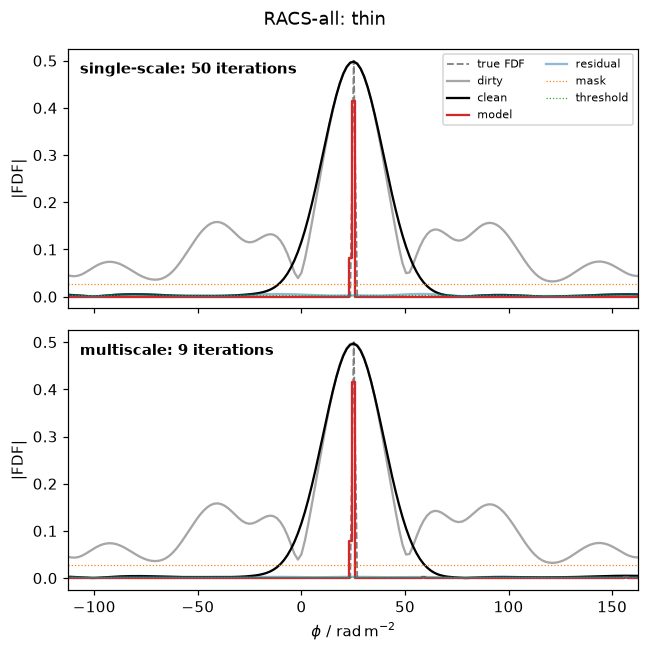

In [5]:
plot_clean(synth, single, multi, "thin", 0.0, rmsf_fwhm, "RACS-all: thin")

### Marginally resolved ($\Delta\phi \approx 1\times$ FWHM)

In [6]:
delta_rm = DELTA_MARGINAL * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

print(f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_MARGINAL:.0f}x FWHM)")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(f"multi:  mom0={multi_mom0:.3f} iterations={multi_n}")

# Depolarised source, but multiscale matches the flux in far fewer iterations.
assert multi_n < single_n
assert multi_mom0 > 0.75 * single_mom0

dRM=34 rad/m^2 (1x FWHM)
single: mom0=0.194 iterations=156
multi:  mom0=0.188 iterations=7


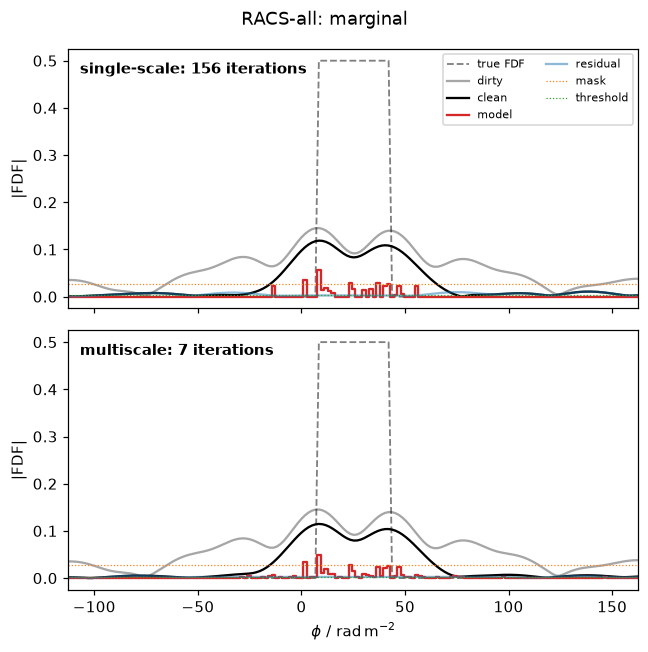

In [7]:
plot_clean(synth, single, multi, "slab", delta_rm, rmsf_fwhm, "RACS-all: marginal")

### Resolved thick ($\Delta\phi \approx 2\times$ FWHM)

About as thick as RACS-all can usefully go: the slab is over half the largest
recoverable scale and heavily depolarised. Multiscale does not recover more flux
here (the structure is near the edge of the usable window), but still describes
it as a few broad features rather than a picket fence of deltas.

In [8]:
delta_rm = DELTA_RESOLVED_RACS * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

print(
    f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_RESOLVED_RACS:.0f}x FWHM, "
    f"{delta_rm / phi_max:.0%} of max scale)"
)
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(f"multi:  mom0={multi_mom0:.3f} iterations={multi_n}")

# Sparse model is the robust win on RACS thick structure.
assert multi_n < single_n
assert multi_n < 25

dRM=69 rad/m^2 (2x FWHM, 61% of max scale)
single: mom0=0.103 iterations=76
multi:  mom0=0.079 iterations=7


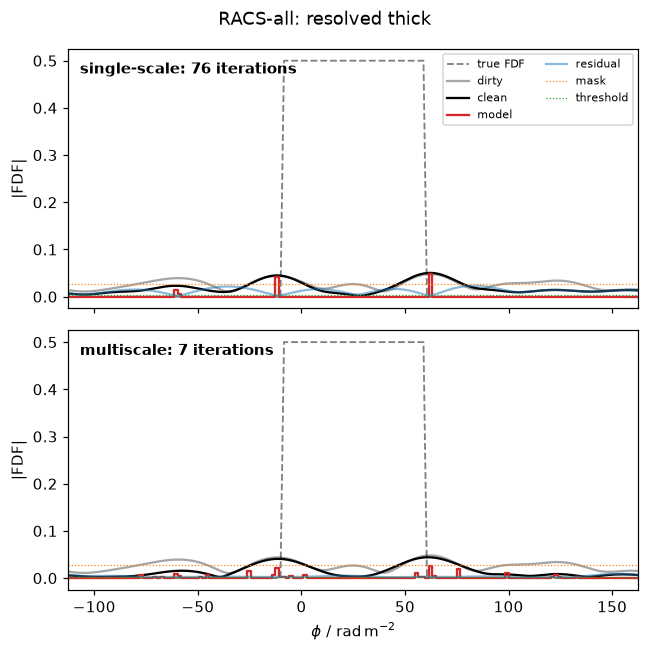

In [9]:
plot_clean(
    synth, single, multi, "slab", delta_rm, rmsf_fwhm, "RACS-all: resolved thick"
)

### Same separation, two thin points

Two Faraday-thin components separated by the same $\Delta\phi$ as the slab above.
Unlike the slab they do not depolarise, so single-scale and multiscale both
recover the full flux; multiscale still does it in far fewer iterations. The
contrast with the slab (same separation, but the slab's flux collapses) shows
that on RACS it is Faraday *thickness*, not separation, that is the problem.

In [10]:
pol = (
    two_thin_points(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

print(f"two thin points separated by {delta_rm:.0f} rad/m^2")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(f"multi:  mom0={multi_mom0:.3f} iterations={multi_n}")

# Two points do not depolarise: near-full flux, fewer multiscale iterations.
assert multi_n < single_n
assert multi_mom0 > 0.8 * FRAC_POL

two thin points separated by 69 rad/m^2
single: mom0=0.495 iterations=89
multi:  mom0=0.494 iterations=8


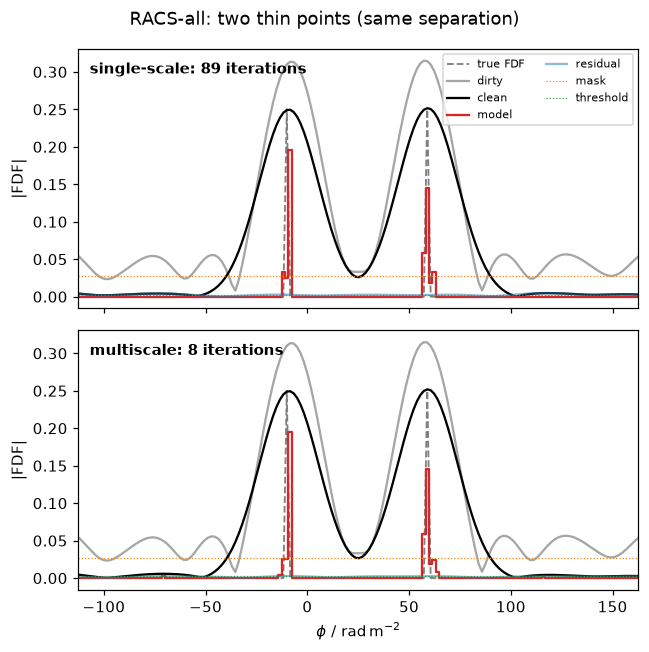

In [11]:
plot_clean(
    synth,
    single,
    multi,
    "points",
    delta_rm,
    rmsf_fwhm,
    "RACS-all: two thin points (same separation)",
)

**RACS-all takeaway:** narrow-band coverage leaves almost no room for resolved
thick sources, and they depolarise quickly, so multiscale buys no extra flux for
a slab. Two thin points at the same separation are recovered fine by both, which
pins the blame on thickness, not separation. Either way multiscale converges in
far fewer iterations.

## GMIMS-DRAGONS coverage

GMIMS-DRAGONS-style coverage is continuous from 0.3 to 1.8 GHz. The dense, wide
$\lambda^2$ span gives a fine RMSF (good Faraday resolution) and a largest
recoverable scale of roughly 19 RMSF FWHM, so genuinely resolved thick structure
both exists and survives.

In [12]:
freq_hz = np.linspace(0.3e9, 1.8e9, 500)
lambda_sq = freq_to_lambda2(freq_hz)

### Thin source ($\Delta\phi = 0$)

In [13]:
pol = (
    burn_slab(lambda_sq, DELTA_THIN)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

rmsf_fwhm = float(synth.fdf_parameters["fwhm_rmsf_radm2"][0])
phi_max = float(synth.fdf_parameters["phi_max_scale_radm2"][0])
print(f"GMIMS-DRAGONS RMSF FWHM = {rmsf_fwhm:.1f} rad/m^2")
print(
    f"max recoverable scale = {phi_max:.0f} rad/m^2 ({phi_max / rmsf_fwhm:.1f} x FWHM)"
)
print(
    f"resolved case dRM = {DELTA_RESOLVED_GMIMS * rmsf_fwhm:.0f} rad/m^2 "
    f"({DELTA_RESOLVED_GMIMS * rmsf_fwhm / phi_max:.0%} of max scale)"
)

multi_model = np.abs(multi.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
multi_model_chan = int((multi_model > 0.01 * multi_model.max()).sum())
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} iterations={multi_n} "
    f"(model spans {multi_model_chan} channels)"
)

assert abs(multi_mom0 - single_mom0) < 0.05
assert 0.40 < multi_mom0 < 0.60
assert multi_n < single_n
assert multi_model_chan <= 8

# Keep the thin-source results to compare against an over-aggressive scale_bias.
synth_thin, multi_thin = synth, multi

GMIMS-DRAGONS RMSF FWHM = 6.1 rad/m^2
max recoverable scale = 113 rad/m^2 (18.6 x FWHM)
resolved case dRM = 37 rad/m^2 (32% of max scale)
single: mom0=0.500 iterations=61
multi:  mom0=0.498 iterations=12 (model spans 2 channels)


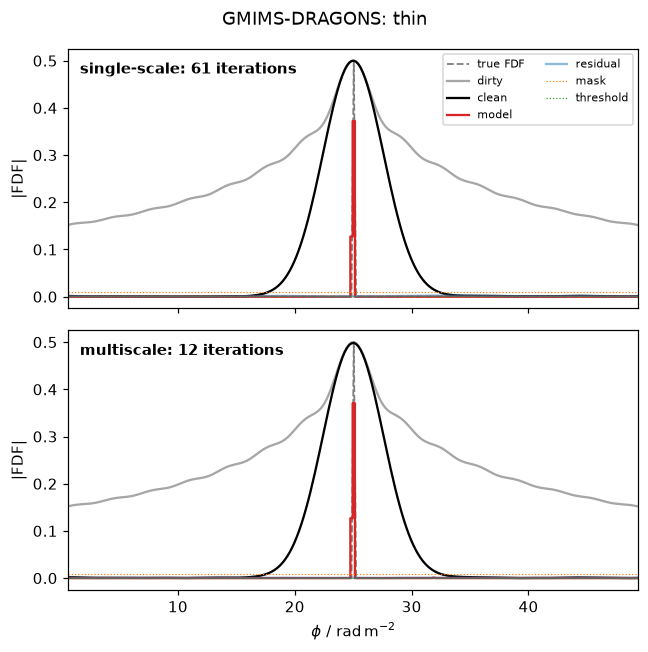

In [14]:
plot_clean(synth, single, multi, "thin", 0.0, rmsf_fwhm, "GMIMS-DRAGONS: thin")

### Marginally resolved ($\Delta\phi \approx 1\times$ FWHM)

In [15]:
delta_rm = DELTA_MARGINAL * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

print(f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_MARGINAL:.0f}x FWHM)")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(f"multi:  mom0={multi_mom0:.3f} iterations={multi_n}")

# Comparable flux, far fewer iterations.
assert multi_n < single_n
assert multi_mom0 > 0.95 * single_mom0

dRM=6 rad/m^2 (1x FWHM)
single: mom0=0.455 iterations=100
multi:  mom0=0.455 iterations=10


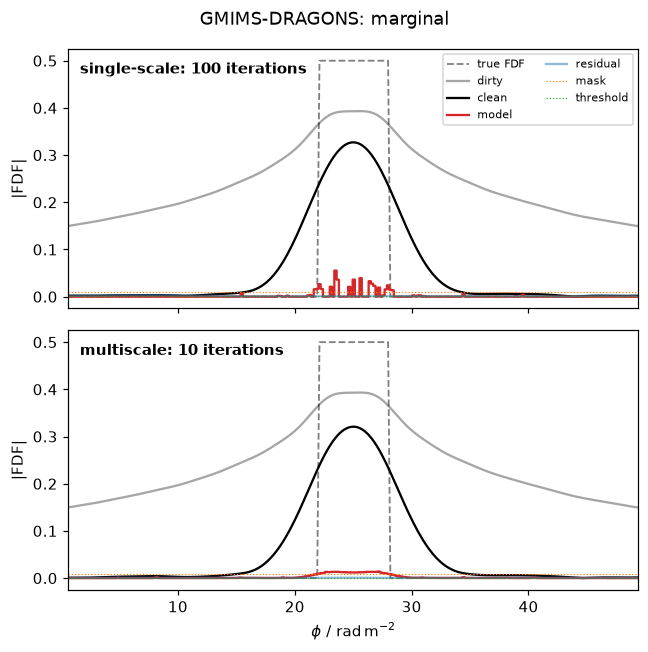

In [16]:
plot_clean(synth, single, multi, "slab", delta_rm, rmsf_fwhm, "GMIMS-DRAGONS: marginal")

### Resolved thick ($\Delta\phi \approx 6\times$ FWHM)

Now the source is genuinely resolved and well inside the recoverable window.
This is where multiscale pays off: comparable-or-better flux than single-scale,
in an order of magnitude fewer iterations, modelled as extended features.

In [17]:
delta_rm = DELTA_RESOLVED_GMIMS * rmsf_fwhm

pol = (
    burn_slab(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

print(
    f"dRM={delta_rm:.0f} rad/m^2 ({DELTA_RESOLVED_GMIMS:.0f}x FWHM, "
    f"{delta_rm / phi_max:.0%} of max scale)"
)
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(f"multi:  mom0={multi_mom0:.3f} iterations={multi_n}")

# The multiscale win: comparable-or-better flux, an order of magnitude fewer iters.
assert multi_n < single_n
assert multi_n * 5 < single_n
assert multi_mom0 > 0.95 * single_mom0

dRM=37 rad/m^2 (6x FWHM, 32% of max scale)
single: mom0=0.315 iterations=312
multi:  mom0=0.312 iterations=9


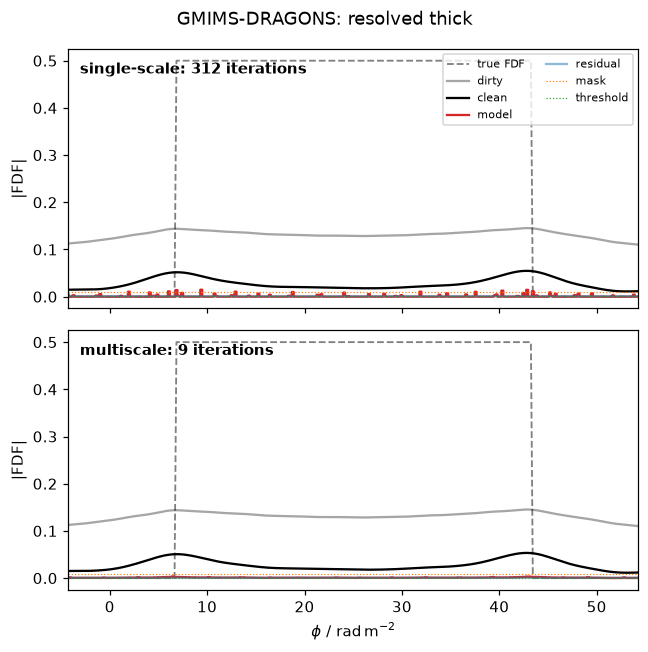

In [18]:
plot_clean(
    synth, single, multi, "slab", delta_rm, rmsf_fwhm, "GMIMS-DRAGONS: resolved thick"
)

### Same separation, two thin points

The same $\Delta\phi$ separation as the resolved slab, but two thin components.
Multiscale keeps them compact (it does not smear two points into a slab) and
recovers the full, undepolarised flux, again in far fewer iterations. Compare
its model to the extended slab model above: multiscale adapts to the source.

In [19]:
pol = (
    two_thin_points(lambda_sq, delta_rm)
    + rng.normal(0, RMS_NOISE, freq_hz.size)
    + 1j * rng.normal(0, RMS_NOISE, freq_hz.size)
).astype(np.complex128)
err = np.ones_like(pol) * (RMS_NOISE + 1j * RMS_NOISE)
with quiet_logs(logging.ERROR):
    synth = rmsynth.run_rmsynth(freq_hz, pol, err, n_samples=20, do_fit_rmsf=True)
    single = rmclean.run_rmclean_from_synth(
        synth, auto_mask=AUTO_MASK, auto_threshold=AUTO_THRESHOLD
    )
    multi = rmclean.run_rmclean_from_synth(
        synth,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

single_mom0 = float(single.fdf_parameters["mom0_debias"][0])
multi_mom0 = float(multi.fdf_parameters["mom0_debias"][0])
single_n = int(np.ravel(single.clean_parameters["n_iter"])[0])
multi_n = int(np.ravel(multi.clean_parameters["n_iter"])[0])

multi_model = np.abs(multi.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
multi_model_chan = int((multi_model > 0.01 * multi_model.max()).sum())
multi_model = np.abs(multi.fdf_arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
multi_model_chan = int((multi_model > 0.01 * multi_model.max()).sum())
print(f"two thin points separated by {delta_rm:.0f} rad/m^2")
print(f"single: mom0={single_mom0:.3f} iterations={single_n}")
print(
    f"multi:  mom0={multi_mom0:.3f} iterations={multi_n} "
    f"(model spans {multi_model_chan} channels)"
)

# Undepolarised: near-full flux; multiscale keeps the two points compact.
assert multi_n < single_n
assert multi_mom0 > 0.85 * FRAC_POL

two thin points separated by 37 rad/m^2
single: mom0=0.498 iterations=134
multi:  mom0=0.498 iterations=18 (model spans 4 channels)


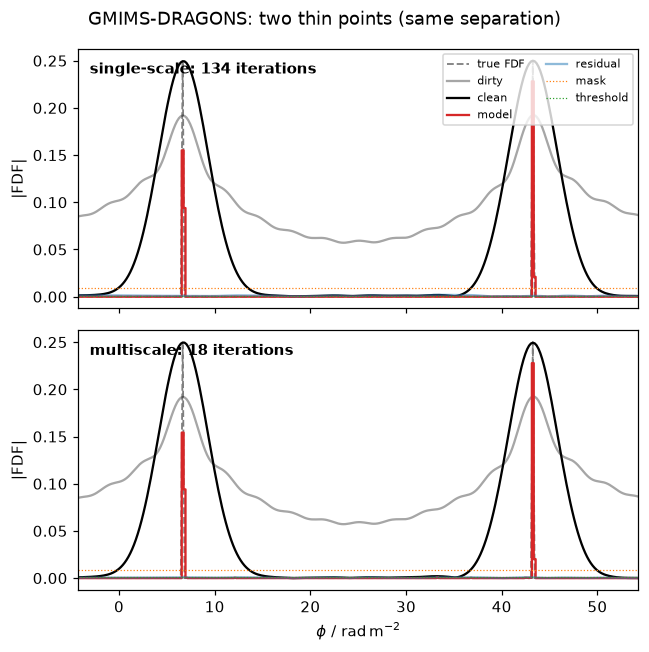

In [20]:
plot_clean(
    synth,
    single,
    multi,
    "points",
    delta_rm,
    rmsf_fwhm,
    "GMIMS-DRAGONS: two thin points (same separation)",
)

### Caution: an over-aggressive `scale_bias`

`multiscale_scale_bias` (Offringa & Smirnov 2017, eq. 3) sets how strongly
larger scales are preferred: near 1 behaves like single-scale, lower favours
larger scales. Because the RMSF is broad relative to the scale kernels, the
per-scale peaks are close together and selection is very sensitive to the bias.
The default 0.95 keeps a thin source a delta; WSClean's image-domain default
(0.6) over-extends it here into a broad, inflated feature. We re-clean the thin
GMIMS source at 0.6 to show it.

scale_bias=0.95: mom0=0.498 half-power width=31 chan
scale_bias=0.6: mom0=0.580 half-power width=38 chan


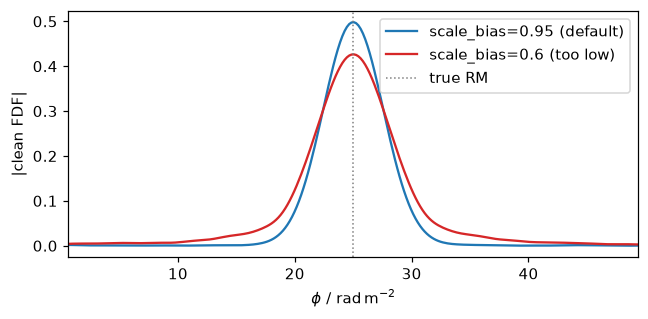

In [21]:
with quiet_logs(logging.ERROR):
    multi_low = rmclean.run_rmclean_from_synth(
        synth_thin,
        auto_mask=AUTO_MASK,
        auto_threshold=AUTO_THRESHOLD,
        multiscale=True,
        multiscale_scale_bias=SCALE_BIAS_LOW,
        multiscale_max_iter_sub_minor=MULTISCALE_MAX_ITER_SUB_MINOR,
    )

phi = synth_thin.fdf_arrs["phi_arr_radm2"].to_numpy().astype(float)
clean_default = np.abs(
    multi_thin.fdf_arrs["fdf_clean_complex_arr"].to_numpy().astype(complex)
)
clean_low = np.abs(
    multi_low.fdf_arrs["fdf_clean_complex_arr"].to_numpy().astype(complex)
)
mom0_default = float(multi_thin.fdf_parameters["mom0_debias"][0])
mom0_low = float(multi_low.fdf_parameters["mom0_debias"][0])
width_default = int((clean_default > clean_default.max() / 2).sum())
width_low = int((clean_low > clean_low.max() / 2).sum())
print(
    f"scale_bias={SCALE_BIAS}: mom0={mom0_default:.3f} half-power width={width_default} chan"
)
print(
    f"scale_bias={SCALE_BIAS_LOW}: mom0={mom0_low:.3f} half-power width={width_low} chan"
)

# Too-low scale_bias over-extends the thin source: inflated flux, broader peak.
assert mom0_low > mom0_default
assert width_low >= width_default

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(
    phi, clean_default, color="tab:blue", label=f"scale_bias={SCALE_BIAS} (default)"
)
ax.plot(phi, clean_low, color="tab:red", label=f"scale_bias={SCALE_BIAS_LOW} (too low)")
ax.axvline(RM_RADM2, color="0.5", ls=":", lw=1, label="true RM")
ax.set(
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="|clean FDF|",
    xlim=(RM_RADM2 - 4 * rmsf_fwhm, RM_RADM2 + 4 * rmsf_fwhm),
)
ax.legend()
fig.tight_layout()

## Summary

| Regime | $\Delta\phi$ / FWHM | Multiscale vs single-scale |
|---|---|---|
| Thin | 0 | matches flux, kept as a delta, fewer iterations; over-extends if `scale_bias` too low |
| Marginal | ~1 | comparable flux, fewer iterations |
| Resolved thick | few (if coverage allows) | comparable-or-better flux, order-of-magnitude fewer iterations |
| Two thin points | any separation | full (undepolarised) flux, kept compact, fewer iterations |

Across both coverages the robust multiscale behaviour is an **adaptive model**:
extended for a genuine slab, compact for points, never a picket fence, reached in
far fewer CLEAN iterations (a major cycle each, not one delta each). Recovered
flux stays comparable to single-scale; narrow-band coverage (RACS-all) leaves
little room for thick sources in the first place.

Reach for multiscale when $\Delta\phi \gtrsim$ RMSF FWHM and the structure is
below $\phi_{\rm max}$. Enable it with `multiscale=True` on
`run_rmclean_from_synth` (1D) or `rmclean_3d_from_synth` (3D); tune with
`multiscale_scale_bias` (default 0.95; lower = stronger large-scale preference,
but too low over-extends compact sources), `multiscale_max_iter_sub_minor`, and
the usual `auto_mask` / `auto_threshold`.